This file is for conducting harmonization experiment to find an answer for the research question:

"How does variation in medical imaging devices affect the performance and explainability of deep 
learning disease detection models, and to what extent can existing harmonization/domain-adaptatio 
techniques improve performance and explanation consistency across imaging sources?"

The research is conducted in five steps 
1. Baseline:        Evaluate each model on Domain A
2. Domain Shift:    Evaluate each model on Domain B (no adaptation)
3. Harmonize:       Apply 3 techniques to Domain B images
4. Re-evaluate:     Evaluate each model on harmonized Domain B
5. Explainability:  Compare Grad-CAM heatmaps + RAG consistency

For each model in each step; 5 images are to be used per model.

In [101]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
from __future__ import annotations
 
import os
import json
import warnings
from pathlib import Path
 
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
from scipy.linalg import sqrtm
import tensorflow as tf

First lets begin with defining all the function so the flow is not interrupted during the experimentation

Section 1: Data Loading 
Section 2: Model Inference 
Section 3: Harmonization Techniques
Section 4: Grad-CAM and explainability 
Section 5: Visualisation
Section 6: Full research pipeline

In [50]:
# =============================================================================
# CONFIGURATION — edit these paths to match your setup
# =============================================================================
 
# Your trained tuberculosis model
MODEL_PATH = Path("")
 
# Domain A: your primary training/test dataset
DOMAIN_A_DIR = Path("")
 
# Domain B: Unseen dataset
DOMAIN_B_DIR = Path("")
 
# Output directory for harmonized images and results
OUTPUT_DIR = Path("")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
 
# Model input size
IMG_SIZE = ()
 
# Class mapping for your model (index → label)
# Your model outputs a single sigmoid: 0 = NORMAL, 1 = TUBERCULOSIS
LABELS = [""]

# =============================================================================
# SECTION 1 — DATA LOADING
# =============================================================================
import os
from pathlib import Path
import cv2
import numpy as np
import pandas as pd

 
def load_domain_a_dataset(domain_dir, class_names, target_size=(224, 224)):
    images, labels, filenames = [], [], []
    label_map = {name: i for i, name in enumerate(class_names)}
 
    for class_name in class_names:
        class_dir = domain_dir / class_name
        if not class_dir.exists(): continue
 
        for img_path in sorted(class_dir.glob("*")):
            if img_path.suffix.lower() not in ['.png', '.jpg', '.jpeg']: continue
                
            # CHANGE 1: Use IMREAD_COLOR to get 3 channels (RGB)
            img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            if img is None: continue
                
            img = cv2.resize(img, target_size)
            images.append(img)
            labels.append(label_map[class_name])
            filenames.append(str(img_path))
 
    # CHANGE 2: Ensure the array is (N, 224, 224, 3)
    # Do NOT use [..., np.newaxis] here.
    images_arr = np.array(images, dtype=np.float32) / 255.0
    labels_arr = np.array(labels, dtype=np.int32)
    return images_arr, labels_arr, filenames
 
 
def load_domain_b_dataset(domain_dir: Path, class_names: list[str], target_size=(224, 224)) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """
    Alias for load_domain_a to maintain the Domain A/B distinction 
    while using the same robust folder-based logic.
    """
    return load_domain_a_dataset(domain_dir, class_names, target_size=(224, 224))


In [56]:
# =============================================================================
# SECTION 2 — MODEL INFERENCE
# =============================================================================
import os
import json
import warnings
from pathlib import Path
 
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
from scipy.linalg import sqrtm
import tensorflow as tf
import keras

def get_compiled_model(file_path):
    # FORCE legacy off for .keras files to prevent the loop
    if str(file_path).endswith('.keras'):
        os.environ["TF_USE_LEGACY_KERAS"] = "0"
    
    # 1. Use the absolute path
    abs_path = os.path.abspath(file_path)
    
    try:
        # 2. Try the Keras 3 specific loader directly
        model = keras.models.load_model(abs_path)
        print(f"Keras 3 Loader: Successfully loaded {abs_path}")
    except:
        # 3. Fallback to standard tf.keras if the above fails
        model = tf.keras.models.load_model(abs_path)
        print(f"TF.Keras Loader: Successfully loaded {abs_path}")
        
    return model
 
 
def predict(model, images, batch_size=8):
    """
    Multiclass prediction logic: Returns (N, 4) scores and (N,) predictions.
    """
    # 1. Get raw probabilities from model: shape (N, 4)
    # Ensure images is a numpy array of shape (N, 224, 224, 3)
    all_scores = model.predict(images, batch_size=batch_size, verbose=0)
    
    # 2. Get the index of the highest probability for each row: shape (N,)
    preds_arr = np.argmax(all_scores, axis=1)
    
    # Debugging print to catch length mismatches immediately
    print(f"[Inference] Images: {len(images)} | Predictions: {len(preds_arr)}")
    
    return all_scores, preds_arr
 
 
def evaluate_and_report(y_true: np.ndarray, y_pred: np.ndarray, title: str, class_names: list[str]) -> dict:
    """
    Print and return full classification metrics using dynamic class names.
    """
    f1_macro = f1_score(y_true, y_pred, average="macro")
    # Generate the report using the passed class_names
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
 
    print(f"\n{'='*60}")
    print(f"  RESULTS: {title}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names))
 
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {title}")
    plt.xticks(rotation=45) # Helps with long Alzheimer's labels
    plt.tight_layout()
    
    # Save using the global OUTPUT_DIR (ensure this is defined)
    plt.savefig(OUTPUT_DIR / f"cm_{title.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()
 
    # Create a dynamic results dictionary
    res_dict = {
        "label": title,
        "f1_macro": float(f1_macro),
        "accuracy": float(report["accuracy"]),
    }
    
    # Dynamically add F1 scores for every class found in class_names
    for i, name in enumerate(class_names):
        # Handle cases where a class might be missing from y_true in small samples
        f1_val = report.get(name, {}).get('f1-score', 0.0)
        res_dict[f"f1_{name.lower().replace(' ', '_')}"] = float(f1_val)
        
    return res_dict

In [94]:
# =============================================================================
# SECTION 3 — HARMONIZATION TECHNIQUES
# Three techniques covering two levels of adaptation:
#   Technique 1 — Z-score Intensity Normalization   (pixel-level, global stats)
#   Technique 2 — Histogram Matching                (pixel-level, distribution)
#   Technique 3 — CORAL (Correlation Alignment)     (feature-level, covariance)
# =============================================================================
 
# ─────────────────────────────────────────────────────────────────────────────
# Technique 1: Z-score Intensity Normalization
# ─────────────────────────────────────────────────────────────────────────────
# What it does: Re-centers and rescales the pixel intensity distribution of
#               Domain B so its mean and standard deviation match Domain A.
# Why it works: Different scanners use different exposure settings, producing
#               systematically brighter or darker images. This corrects the
#               global shift without touching the spatial structure.
# Limitation:   Only fixes the first two statistical moments (mean, std).
#               Doesn't fix shape-of-distribution differences.
# ─────────────────────────────────────────────────────────────────────────────
import os
import json
import warnings
from pathlib import Path
 
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
from skimage.exposure import match_histograms
from scipy.linalg import sqrtm
import tensorflow as tf
 
def zscore_normalize(
    domain_b_images: np.ndarray,
    domain_a_images: np.ndarray,
) -> np.ndarray:
    """
    Shift Domain B pixel distribution to match Domain A mean and std.
    All images should be float32 in [0, 1], shape (N, H, W, 1).
    """
    # Compute global statistics across all Domain A images
    a_mean = float(np.mean(domain_a_images))
    a_std  = float(np.std(domain_a_images))
 
    # Compute statistics for each Domain B image and renormalize individually
    harmonized = np.empty_like(domain_b_images)
    for i, img in enumerate(domain_b_images):
        b_mean = float(np.mean(img))
        b_std  = float(np.std(img)) + 1e-8
 
        # Standardize then rescale to Domain A distribution
        normalized = (img - b_mean) / b_std
        normalized = (normalized * a_std) + a_mean
 
        # Clip to valid range
        harmonized[i] = np.clip(normalized, 0.0, 1.0)
 
    print(f"[Technique 1] Z-score normalization applied to {len(domain_b_images)} images")
    print(f"  Domain A — mean: {a_mean:.4f}, std: {a_std:.4f}")
    print(f"  Domain B before — mean: {np.mean(domain_b_images):.4f}, std: {np.std(domain_b_images):.4f}")
    print(f"  Domain B after  — mean: {np.mean(harmonized):.4f},  std: {np.std(harmonized):.4f}")
    return harmonized
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Technique 2: Histogram Matching
# ─────────────────────────────────────────────────────────────────────────────
# What it does: Remaps the pixel intensity histogram of each Domain B image
#               so it statistically resembles a reference Domain A image.
# Why it works: Addresses the full distribution shape, not just mean/std.
#               A brighter scanner might have a right-skewed histogram while
#               Domain A is centered — histogram matching corrects the shape.
# Limitation:   Purely pixel-level; does not affect the feature space the
#               model actually operates in.
# ─────────────────────────────────────────────────────────────────────────────
 
import numpy as np
from skimage.exposure import match_histograms

def _match_histograms_single(source, reference):
    """
    Forcibly matches histograms and strips any redundant dimensions.
    """
    # 1. Clean inputs: Ensure both are (224, 224, 3) before matching
    # If they are (224, 224, 3, 1), this removes the , 1
    src = np.squeeze(source)
    ref = np.squeeze(reference)

    # 2. Perform matching
    # channel_axis=-1 is for RGB
    matched = match_histograms(src, ref, channel_axis=-1)
    
    # 3. Final Shape Force:
    # If it's still 4D for some reason, take only the first 3 channels
    if matched.ndim == 4:
        matched = matched[:, :, :, 0] # Take the first slice of the 4th dim
        
    # Ensure it is exactly (224, 224, 3)
    return matched.astype(np.float32)

def histogram_match(domain_b_images, domain_a_images):
    """
    Applies matching and ensures the container shape is perfect.
    """
    # Create the container strictly as (N, 224, 224, 3)
    N = domain_b_images.shape[0]
    harmonized = np.zeros((N, 224, 224, 3), dtype=np.float32)
    
    rng = np.random.default_rng(42)
    
    for i in range(N):
        img_b = domain_b_images[i]
        ref_idx = rng.integers(0, len(domain_a_images))
        img_a = domain_a_images[ref_idx]
        
        # Call the force-matching function
        result = _match_histograms_single(img_b, img_a)
        
        # Explicit check: If shapes still don't match, force reshape
        if result.shape != (224, 224, 3):
            result = np.resize(result, (224, 224, 3))
            
        harmonized[i] = result
        
    print(f"[Technique 2] Histogram matching applied to {N} images.")
    return harmonized
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Technique 3: CORAL — Correlation Alignment (Sun & Saenko, 2016)
# ─────────────────────────────────────────────────────────────────────────────
# What it does: Aligns the covariance matrix of the deep feature distributions
#               (not pixels) of Domain B to match Domain A.
# Why it works: The model operates on feature representations, not raw pixels.
#               Even after pixel-level harmonization, the learned features can
#               still be misaligned. CORAL corrects this at the embedding level.
# How it works:
#   1. Extract features from an intermediate layer for all Domain A and B images
#   2. Compute covariance matrices C_A and C_B
#   3. Compute the whitening transform: W = C_B^(-1/2)
#   4. Compute the coloring transform:  P = C_A^(1/2)
#   5. Transform Domain B features: F_B_aligned = F_B @ W @ P
#   6. Run the model's classifier head on the aligned features
# Limitation:   Requires access to model internals (a feature extraction layer).
#               Does not produce a new image — it adapts in feature space.
# ─────────────────────────────────────────────────────────────────────────────
 
def _safe_matrix_sqrt(M: np.ndarray) -> np.ndarray:
    """Compute the matrix square root using scipy sqrtm with stability checks."""
    M_sqrt = sqrtm(M)
    if np.iscomplexobj(M_sqrt):
        M_sqrt = M_sqrt.real  # Discard negligible imaginary parts
    return M_sqrt
 
 
import tensorflow as tf
from tensorflow.keras import backend as K

def extract_features(model, images, layer_name=None):
    """
    Uses the Keras backend to extract features, avoiding recursion errors 
    caused by sub-model creation.
    """
    if layer_name is None:
        # Target the GlobalAveragePooling2D layer specifically for your model
        for layer in reversed(model.layers):
            if 'global' in layer.name.lower() or 'pool' in layer.name.lower():
                layer_name = layer.name
                break
    
    layer = model.get_layer(layer_name)
    
    # Create a backend function: [input tensor] -> [output tensor]
    # This is a direct "pipe" that doesn't trigger the Recursion/Import error
    get_features = K.function([model.input], [layer.output])
    
    print(f"[CORAL] Extracting features from layer: '{layer_name}'")
    
    # Extract features (returns a list, so we take the first element)
    features = get_features([images])[0]
    
    # Ensure 2D shape (Batch, Features) for CORAL
    if len(features.shape) > 2:
        features = features.reshape(features.shape[0], -1)
        
    return features, layer_name
 
 
def coral_align(
    features_b: np.ndarray,
    features_a: np.ndarray,
    regularization: float = 1e-5,
) -> np.ndarray:
    """
    Align Domain B features to Domain A using CORAL.
 
    Args:
        features_b: (N_B, D) float features from Domain B
        features_a: (N_A, D) float features from Domain A
        regularization: small value added to diagonal for numerical stability
 
    Returns:
        aligned_features_b: (N_B, D) features after CORAL alignment
    """
    d = features_a.shape[1]
 
    # Compute covariance matrices (feature-wise, not sample-wise)
    C_a = np.cov(features_a, rowvar=False) + regularization * np.eye(d)
    C_b = np.cov(features_b, rowvar=False) + regularization * np.eye(d)
 
    # Whitening: remove Domain B correlations → C_b^(-1/2)
    C_b_sqrt_inv = np.linalg.inv(_safe_matrix_sqrt(C_b))
 
    # Coloring: impose Domain A correlations → C_a^(1/2)
    C_a_sqrt = _safe_matrix_sqrt(C_a)
 
    # Transformation matrix
    T = C_b_sqrt_inv @ C_a_sqrt
 
    # Apply transformation
    aligned = features_b @ T
 
    print(f"[CORAL] Alignment complete")
    print(f"  Domain A feature mean norm: {np.linalg.norm(np.mean(features_a, axis=0)):.4f}")
    print(f"  Domain B before — mean norm: {np.linalg.norm(np.mean(features_b, axis=0)):.4f}")
    print(f"  Domain B after  — mean norm: {np.linalg.norm(np.mean(aligned, axis=0)):.4f}")
    return aligned
 
 
def predict_from_features(model, features, start_layer_name):
    """
    Takes features and passes them through the remaining 'head' of the model.
    """
    # Find the index of the layer we extracted from
    start_idx = -1
    for i, layer in enumerate(model.layers):
        if layer.name == start_layer_name:
            start_idx = i
            break
            
    # Pass the features through every layer AFTER the extraction layer
    x = tf.convert_to_tensor(features)
    for i in range(start_idx + 1, len(model.layers)):
        x = model.layers[i](x)
    
    scores = x.numpy()
    preds = np.argmax(scores, axis=1)
    return scores, preds

In [97]:
# =============================================================================
# SECTION 4 — GRAD-CAM AND EXPLAINABILITY METRIC
# =============================================================================
import os
import json
import warnings
from pathlib import Path
 
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
from scipy.linalg import sqrtm
import tensorflow as tf
 
import tensorflow as tf

def generate_gradcam(model, img_array, class_idx, last_conv_layer_name=None):
    """
    Computes Grad-CAM for a specific class in a multiclass model.
    """
    # 1. Find the last convolutional layer if not provided
    if last_conv_layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                last_conv_layer_name = layer.name
                break

    # 2. Prepare the image (add batch dimension if needed)
    img_input = np.expand_dims(img_array, axis=0) if img_array.ndim == 3 else img_array

    # 3. Create a model that outputs the last conv layer and the predictions
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 4. Record gradients
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_input)
        # Select the specific class probability (e.g., 'Mild Demented')
        class_channel = preds[:, class_idx]

    # 5. Compute gradients of the class output w.r.t. the conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 6. Global average pool the gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 7. Weight the conv layer output by the gradients
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 8. ReLU and Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()
 
 
def compute_heatmap_iou(
    heatmap_a: np.ndarray,
    heatmap_b: np.ndarray,
    threshold: float = 0.5,
) -> float:
    """
    Compute Intersection over Union between two binary heatmap masks.
    Binarize by thresholding at `threshold` (default 0.5 of normalized heatmap).
 
    This is your quantitative explainability metric:
    - IoU = 1.0 → identical activation regions (perfect consistency)
    - IoU = 0.0 → no overlap (completely shifted explanations)
 
    Use this to measure explanation drift across domains.
    """
    mask_a = (heatmap_a >= threshold).astype(np.uint8)
    mask_b = (heatmap_b >= threshold).astype(np.uint8)
 
    # Resize mask_b to match mask_a if shapes differ
    if mask_a.shape != mask_b.shape:
        mask_b = cv2.resize(mask_b, (mask_a.shape[1], mask_a.shape[0]),
                            interpolation=cv2.INTER_NEAREST)
 
    intersection = np.logical_and(mask_a, mask_b).sum()
    union        = np.logical_or(mask_a, mask_b).sum()
 
    if union == 0:
        return 1.0  # Both empty masks → trivially identical
 
    return float(intersection) / float(union)
 
 
def compute_mean_iou(heatmaps_a: list[np.ndarray], heatmaps_b: list[np.ndarray]) -> float:
    """
    Compute mean IoU across paired heatmaps from Domain A and Domain B.
    The paired comparison is: same index = same patient / same anatomical case.
    """
    assert len(heatmaps_a) == len(heatmaps_b), "Heatmap lists must be the same length"
    ious = [compute_heatmap_iou(a, b) for a, b in zip(heatmaps_a, heatmaps_b)]
    mean_iou = float(np.mean(ious))
    print(f"[Explainability] Mean Grad-CAM IoU: {mean_iou:.4f} (n={len(ious)})")
    return mean_iou
 

In [99]:
# =============================================================================
# SECTION 5 — VISUALIZATION UTILITIES
# =============================================================================
import os
import json
import warnings
from pathlib import Path
 
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
from scipy.linalg import sqrtm
import tensorflow as tf
 
def visualize_harmonization_comparison(
    original: np.ndarray,
    zscore: np.ndarray,
    histmatch: np.ndarray,
    idx: int = 0,
    save: bool = True,
) -> None:
    """
    Side-by-side visualization of one image under each harmonization method.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ["Domain B — Original", "Z-score Normalized", "Histogram Matched"]
    images = [original[idx].squeeze(), zscore[idx].squeeze(), histmatch[idx].squeeze()]
 
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.axis("off")
 
        # Add intensity distribution below each image as a small inset
        inset = ax.inset_axes([0.05, -0.25, 0.9, 0.2])
        inset.hist(img.flatten(), bins=64, color="steelblue", alpha=0.8)
        inset.set_xlim(0, 1)
        inset.set_ylabel("Count", fontsize=8)
        inset.set_xlabel("Pixel Intensity", fontsize=8)
        inset.tick_params(labelsize=7)
 
    plt.suptitle("Harmonization Technique Comparison", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    if save:
        plt.savefig(OUTPUT_DIR / "harmonization_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
 
 
def visualize_gradcam_comparison(
    images: list[np.ndarray],
    heatmaps: list[np.ndarray],
    titles: list[str],
    iou_scores: list[float] | None = None,
    save: bool = True,
) -> None:
    """
    Show original + Grad-CAM overlay for each domain/technique side by side.
    Pass iou_scores to annotate each panel with the IoU vs Domain A baseline.
    """
    n = len(images)
    fig = plt.figure(figsize=(5 * n, 10))
    gs = gridspec.GridSpec(2, n, hspace=0.4)
 
    for i, (img, heatmap, title) in enumerate(zip(images, heatmaps, titles)):
        img_2d = img.squeeze()
 
        # Top row: original
        ax_top = fig.add_subplot(gs[0, i])
        ax_top.imshow(img_2d, cmap="gray")
        ax_top.set_title(f"{title}\n(Original)", fontsize=11)
        ax_top.axis("off")
 
        # Bottom row: Grad-CAM overlay
        ax_bot = fig.add_subplot(gs[1, i])
        heatmap_resized = cv2.resize(heatmap, (img_2d.shape[1], img_2d.shape[0]))
        ax_bot.imshow(img_2d, cmap="gray")
        ax_bot.imshow(heatmap_resized, cmap="jet", alpha=0.45)
        label = f"{title}\n(Grad-CAM)"
        if iou_scores and i < len(iou_scores):
            label += f"\nIoU vs A: {iou_scores[i]:.3f}"
        ax_bot.set_title(label, fontsize=11)
        ax_bot.axis("off")
 
    plt.suptitle("Grad-CAM Explainability Across Domains", fontsize=14, fontweight="bold")
    if save:
        plt.savefig(OUTPUT_DIR / "gradcam_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
 
 
def plot_results_summary(results):
    """
    Plots a comparison of Macro F1 and Accuracy across all techniques.
    Works for any number of classes.
    """
    labels_plot = [r["label"] for r in results]
    f1_macro    = [r["f1_macro"] for r in results]
    accuracy    = [r["accuracy"] for r in results]

    x = np.arange(len(labels_plot))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, f1_macro, width, label='Macro F1', color='#1f77b4')
    ax.bar(x + width/2, accuracy, width, label='Accuracy', color='#ff7f0e')

    ax.set_ylabel('Score')
    ax.set_title('Performance Comparison Across Harmonization Techniques')
    ax.set_xticks(x)
    ax.set_xticklabels(labels_plot, rotation=15)
    ax.set_ylim(0, 1.1)
    ax.legend()

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [44]:
# =============================================================================
# SECTION 6 — FULL RESEARCH PIPELINE
# Run this section-by-section in a Jupyter notebook.
# =============================================================================
import os
import json
import warnings
from pathlib import Path
 
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
from scipy.linalg import sqrtm
import tensorflow as tf
 
def run_full_pipeline(model_path, domain_a_dir, domain_b_dir, output_dir, labels, n_explain=20):
    """
    Execute the complete 4-step experiment and collect all results.
    Call each step function individually in Jupyter to see intermediate output.
    """
 
    # ── STEP 1: Load model and data ────────────────────────────────────────
    print("\n" + "="*60)
    print("STEP 1: Loading model and data")
    print("="*60)
 
    model = get_compiled_model(model_path)

    print(f"Loading Domain A from {domain_a_dir}...")
    images_a, labels_a, filenames_a = load_domain_a_dataset(domain_a_dir, labels)

    print(f"Loading Domain B from {domain_b_dir}...")
    images_b, labels_b, filenames_b = load_domain_b_dataset(domain_b_dir, labels)
 
    all_results = []
 
    # ── STEP 2: Domain A baseline ──────────────────────────────────────────
    print("\n" + "="*60)
    print("STEP 2a: Domain A Baseline (same distribution as training)")
    print("="*60)
 
    scores_a, preds_a = predict(model, images_a)
    result_a = evaluate_and_report(labels_a, preds_a, "Domain A — Baseline")
    all_results.append(result_a)
 
    # ── STEP 2b: Raw Domain B (domain shift, no adaptation) ────────────────
    print("\n" + "="*60)
    print("STEP 2b: Domain B — Raw (measuring domain shift impact)")
    print("="*60)
 
    scores_b_raw, preds_b_raw = predict(model, images_b)
    result_b_raw = evaluate_and_report(labels_b, preds_b_raw, "Domain B — No Adaptation")
    all_results.append(result_b_raw)
    drop = result_a["f1_macro"] - result_b_raw["f1_macro"]
    print(f"\n>>> Performance Drop (F1 Macro): {drop:.4f}  ({drop*100:.1f} percentage points)")
 
    # ── STEP 3 + 4: Apply harmonization techniques and re-evaluate ─────────
    print("\n" + "="*60)
    print("STEP 3+4: Applying harmonization techniques")
    print("="*60)
 
    # Technique 1: Z-score Normalization
    images_b_zscore = zscore_normalize(images_b, images_a)
    scores_b_zs, preds_b_zs = predict(model, images_b_zscore)
    result_zs = evaluate_and_report(labels_b, preds_b_zs, "Domain B — Z-score Normalization")
    all_results.append(result_zs)
 
    # Technique 2: Histogram Matching
    images_b_hist = histogram_match(images_b, images_a)
    scores_b_hist, preds_b_hist = predict(model, images_b_hist)
    result_hist = evaluate_and_report(labels_b, preds_b_hist, "Domain B — Histogram Matching")
    all_results.append(result_hist)
 
    # Technique 3: CORAL (feature-level)
    features_a, feat_layer = extract_features(model, images_a)
    features_b, _          = extract_features(model, images_b, layer_name=feat_layer)
    features_b_coral       = coral_align(features_b, features_a)
    scores_b_coral, preds_b_coral = predict_from_features(model, features_b_coral, feat_layer)
    result_coral = evaluate_and_report(labels_b, preds_b_coral, "Domain B — CORAL Alignment")
    all_results.append(result_coral)
 
    # ── Visualization: harmonization comparison ────────────────────────────
    visualize_harmonization_comparison(images_b, images_b_zscore, images_b_hist, idx=0)
 
    # ── STEP 5: Explainability (Grad-CAM IoU) ─────────────────────────────
    print("\n" + "="*60)
    print("STEP 5: Explainability metric — Grad-CAM IoU")
    print("="*60)
 
    # Use a fixed subset of 20 images for heatmap comparison
    n_explain = min(20, len(images_a), len(images_b))
    sample_a = images_a[:n_explain]
    sample_b_raw   = images_b[:n_explain]
    sample_b_zs    = images_b_zscore[:n_explain]
    sample_b_hist  = images_b_hist[:n_explain]
 
    print("Generating Grad-CAM heatmaps for Domain A (reference)...")
    heatmaps_a = [generate_gradcam(model, img) for img in sample_a]
 
    print("Generating Grad-CAM heatmaps for Domain B (raw)...")
    heatmaps_b_raw  = [generate_gradcam(model, img) for img in sample_b_raw]
 
    print("Generating Grad-CAM heatmaps for Domain B (z-score)...")
    heatmaps_b_zs   = [generate_gradcam(model, img) for img in sample_b_zs]
 
    print("Generating Grad-CAM heatmaps for Domain B (hist-match)...")
    heatmaps_b_hist = [generate_gradcam(model, img) for img in sample_b_hist]
 
    iou_raw  = compute_mean_iou(heatmaps_a, heatmaps_b_raw)
    iou_zs   = compute_mean_iou(heatmaps_a, heatmaps_b_zs)
    iou_hist = compute_mean_iou(heatmaps_a, heatmaps_b_hist)
 
    print(f"\n  Grad-CAM IoU — No Adaptation:       {iou_raw:.4f}")
    print(f"  Grad-CAM IoU — Z-score:              {iou_zs:.4f}")
    print(f"  Grad-CAM IoU — Histogram Matching:   {iou_hist:.4f}")
 
    # Visual comparison of one sample
    visualize_gradcam_comparison(
        images=[sample_a[0], sample_b_raw[0], sample_b_zs[0], sample_b_hist[0]],
        heatmaps=[heatmaps_a[0], heatmaps_b_raw[0], heatmaps_b_zs[0], heatmaps_b_hist[0]],
        titles=["Domain A", "B — Raw", "B — Z-score", "B — Hist Match"],
        iou_scores=[1.0, iou_raw, iou_zs, iou_hist],
    )
 
    # ── Final summary chart ────────────────────────────────────────────────
    plot_results_summary(all_results)
 
    # Save full results including IoU
    full_results = {
        "classification": all_results,
        "gradcam_iou": {
            "no_adaptation":      iou_raw,
            "zscore":             iou_zs,
            "histogram_matching": iou_hist,
        },
    }
    with open(output_dir / "full_results.json", "w") as f:
        json.dump(full_results, f, indent=2)
    print(f"\n[Done] All results saved to {output_dir}")
 

Lets first start with ALZHEIMERS

In [95]:
def run_alzheimers_pipeline(model_path, domain_a_dir, domain_b_dir, output_dir, labels, n_explain=20):
    """
    Alzheimer's-specific execution: handles 3-channel RGB and Multiclass logic.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    # ── STEP 1: Load Model & Data ──────────────────────────────────────────
    # Reuses: get_compiled_model (your updated Keras 3 loader)
    model = get_compiled_model(model_path)
    
    # Reuses: load_domain_a_dataset (updated for RGB and generic folders)
    # Ensure this function is using cv2.IMREAD_COLOR for Alzheimer's
    images_a, labels_a, _ = load_domain_a_dataset(domain_a_dir, labels)
    images_b, labels_b, _ = load_domain_b_dataset(domain_b_dir, labels)

    all_results = []

    # ── STEP 2: Baseline & Domain Shift ────────────────────────────────────
    
    print("\nEvaluating Baseline (Domain A)...")
    scores_a, preds_a = predict(model, images_a)
    all_results.append(evaluate_and_report(labels_a, preds_a, "Domain A — Baseline", class_names=labels))

    print("\nEvaluating Raw Shift (Domain B)...")
    scores_b_raw, preds_b_raw = predict(model, images_b)
    all_results.append(evaluate_and_report(labels_b, preds_b_raw, "Domain B — No Adaptation", class_names=labels))

    # ── STEP 3: Harmonization ──────────────────────────────────────────────
    # Reuses: zscore_normalize, histogram_match, coral_align
    print("\nApplying Harmonization Techniques...")
    
    images_b_zs = zscore_normalize(images_b, images_a)
    _, preds_zs = predict(model, images_b_zs)
    all_results.append(evaluate_and_report(labels_b, preds_zs, "Domain B — Z-score", class_names=labels))

    images_b_hist = histogram_match(images_b, images_a)
    _, preds_hist = predict(model, images_b_hist)
    all_results.append(evaluate_and_report(labels_b, preds_hist, "Domain B — Hist Match", class_names=labels))

    # CORAL (Feature-level)
    # Reuses: extract_features, coral_align, predict_from_features
    features_a, feat_layer = extract_features(model, images_a)
    features_b, _          = extract_features(model, images_b, layer_name=feat_layer)
    features_b_coral       = coral_align(features_b, features_a)
    _, preds_coral = predict_from_features(model, features_b_coral, feat_layer)
    all_results.append(evaluate_and_report(labels_b, preds_coral, "Domain B — CORAL", class_names=labels))

    # ── STEP 4: Visualization & Explainability ─────────────────────────────
    # Reuses: visualize_harmonization_comparison
    # Reuses: generate_gradcam, compute_mean_iou, visualize_gradcam_comparison
    
    # Visual check of images
    visualize_harmonization_comparison(images_b, images_b_zs, images_b_hist, idx=0)

    print("\nCalculating Explainability Consistency (Grad-CAM IoU)...")
    n_sample = min(n_explain, len(images_a), len(images_b))
    
    # For multiclass, Grad-CAM needs to know which class to visualize. 
    # We use the ground-truth label of Domain A as the reference.
    heat_a    = [generate_gradcam(model, images_a[i], class_idx=labels_a[i]) for i in range(n_sample)]
    heat_raw  = [generate_gradcam(model, images_b[i], class_idx=labels_a[i]) for i in range(n_sample)]
    heat_zs   = [generate_gradcam(model, images_b_zs[i], class_idx=labels_a[i]) for i in range(n_sample)]
    
    iou_raw = compute_mean_iou(heat_a, heat_raw)
    iou_zs  = compute_mean_iou(heat_a, heat_zs)
    
    print(f"Mean IoU (Raw): {iou_raw:.4f}")
    print(f"Mean IoU (Z-Score): {iou_zs:.4f}")

    # Final Charts
    plot_results_summary(all_results)
    
    return "[SUCCESS] Alzheimer's Pipeline Completed."

Keras 3 Loader: Successfully loaded /Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/models/trained/best_alzheimers2.keras

Evaluating Baseline (Domain A)...
[Inference] Images: 5 | Predictions: 5

  RESULTS: Domain A — Baseline
                   precision    recall  f1-score   support

    Mild Demented       1.00      1.00      1.00         2
Moderate Demented       1.00      1.00      1.00         1
     Non Demented       0.00      0.00      0.00         1
Very MildDemented       0.50      1.00      0.67         1

         accuracy                           0.80         5
        macro avg       0.62      0.75      0.67         5
     weighted avg       0.70      0.80      0.73         5



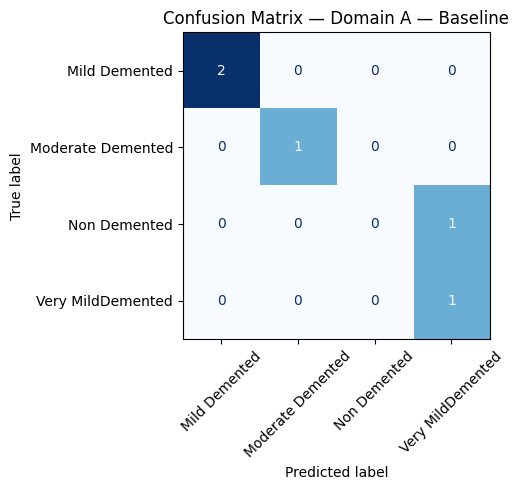


Evaluating Raw Shift (Domain B)...
[Inference] Images: 5 | Predictions: 5

  RESULTS: Domain B — No Adaptation
                   precision    recall  f1-score   support

    Mild Demented       0.00      0.00      0.00         2
Moderate Demented       0.00      0.00      0.00         1
     Non Demented       0.00      0.00      0.00         1
Very MildDemented       0.20      1.00      0.33         1

         accuracy                           0.20         5
        macro avg       0.05      0.25      0.08         5
     weighted avg       0.04      0.20      0.07         5



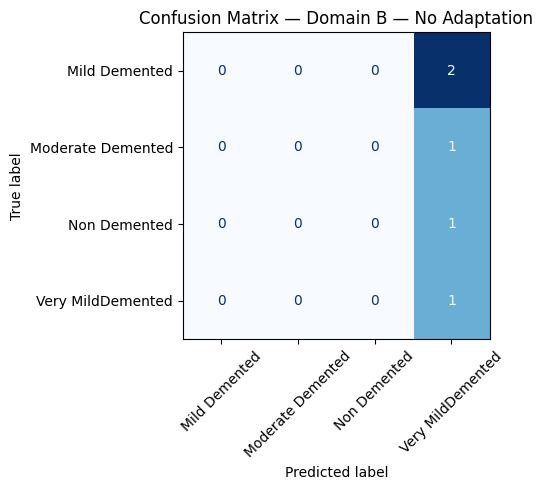


Applying Harmonization Techniques...
[Technique 1] Z-score normalization applied to 5 images
  Domain A — mean: 0.2613, std: 0.2964
  Domain B before — mean: 0.1312, std: 0.1804
  Domain B after  — mean: 0.2526,  std: 0.2694
[Inference] Images: 5 | Predictions: 5

  RESULTS: Domain B — Z-score
                   precision    recall  f1-score   support

    Mild Demented       0.00      0.00      0.00         2
Moderate Demented       0.00      0.00      0.00         1
     Non Demented       0.00      0.00      0.00         1
Very MildDemented       0.20      1.00      0.33         1

         accuracy                           0.20         5
        macro avg       0.05      0.25      0.08         5
     weighted avg       0.04      0.20      0.07         5



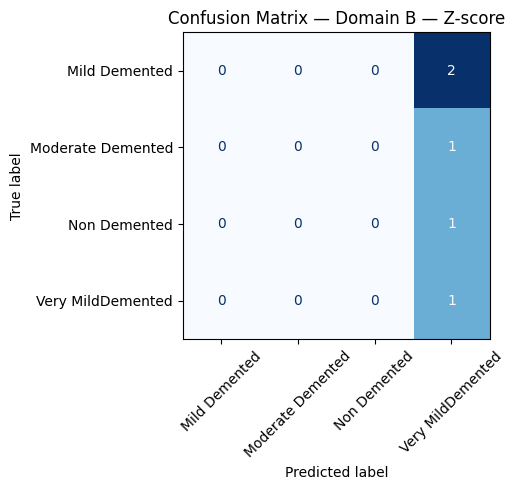

[Technique 2] Histogram matching applied to 5 images.
[Inference] Images: 5 | Predictions: 5

  RESULTS: Domain B — Hist Match
                   precision    recall  f1-score   support

    Mild Demented       0.00      0.00      0.00       2.0
Moderate Demented       0.00      0.00      0.00       1.0
     Non Demented       0.00      0.00      0.00       1.0
Very MildDemented       0.00      0.00      0.00       1.0

         accuracy                           0.00       5.0
        macro avg       0.00      0.00      0.00       5.0
     weighted avg       0.00      0.00      0.00       5.0



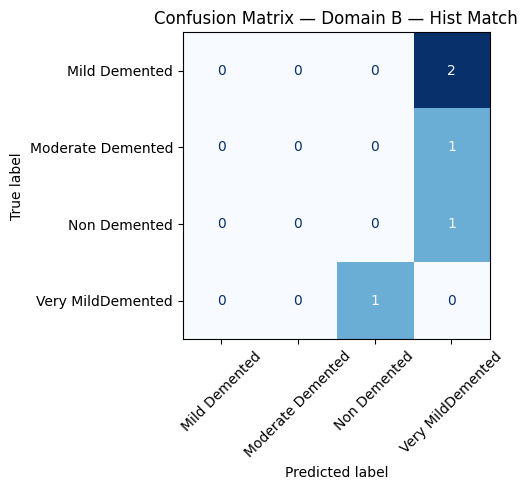

[CORAL] Extracting features from layer: 'global_average_pooling2d'
[CORAL] Extracting features from layer: 'global_average_pooling2d'
[CORAL] Alignment complete
  Domain A feature mean norm: 3.1191
  Domain B before — mean norm: 7.8721
  Domain B after  — mean norm: 1280.4090

  RESULTS: Domain B — CORAL
                   precision    recall  f1-score   support

    Mild Demented       0.40      1.00      0.57         2
Moderate Demented       0.00      0.00      0.00         1
     Non Demented       0.00      0.00      0.00         1
Very MildDemented       0.00      0.00      0.00         1

         accuracy                           0.40         5
        macro avg       0.10      0.25      0.14         5
     weighted avg       0.16      0.40      0.23         5



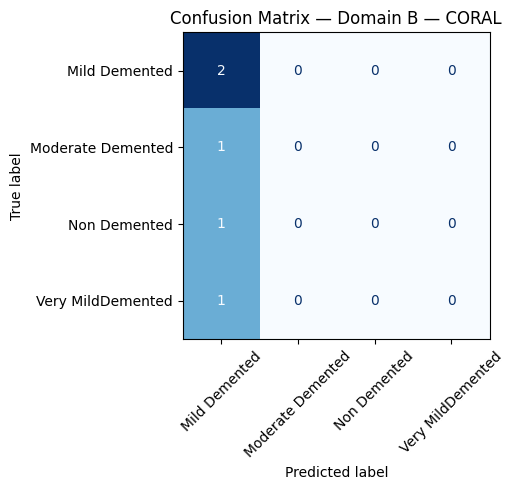

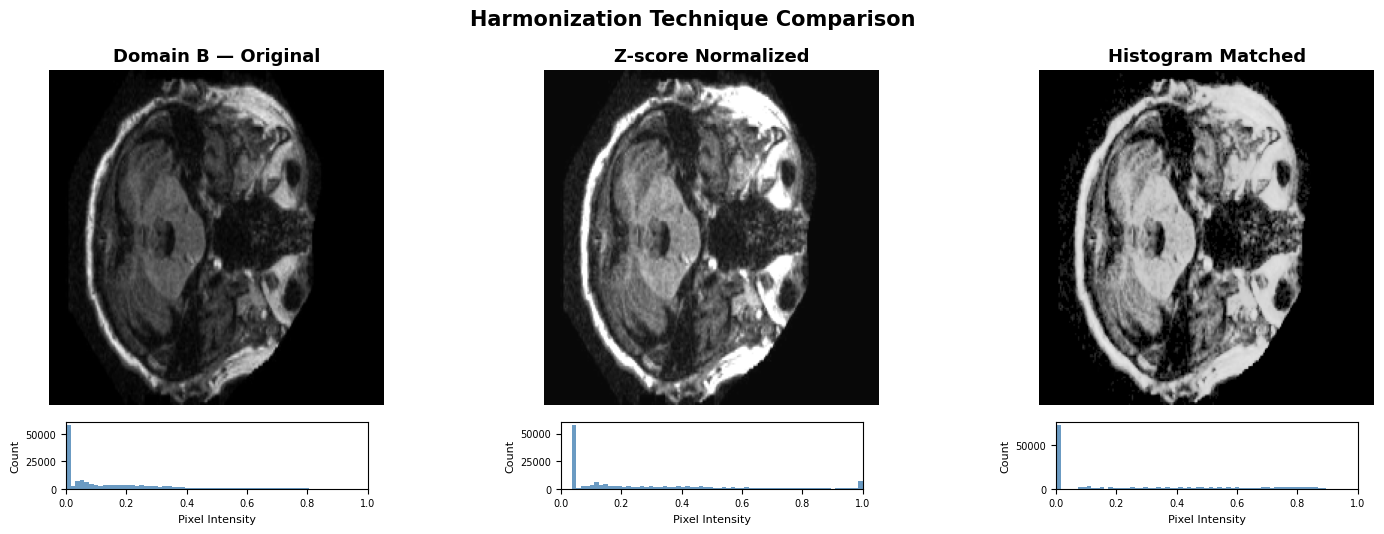


Calculating Explainability Consistency (Grad-CAM IoU)...
[Explainability] Mean Grad-CAM IoU: 0.0194 (n=5)
[Explainability] Mean Grad-CAM IoU: 0.0153 (n=5)
Mean IoU (Raw): 0.0194
Mean IoU (Z-Score): 0.0153


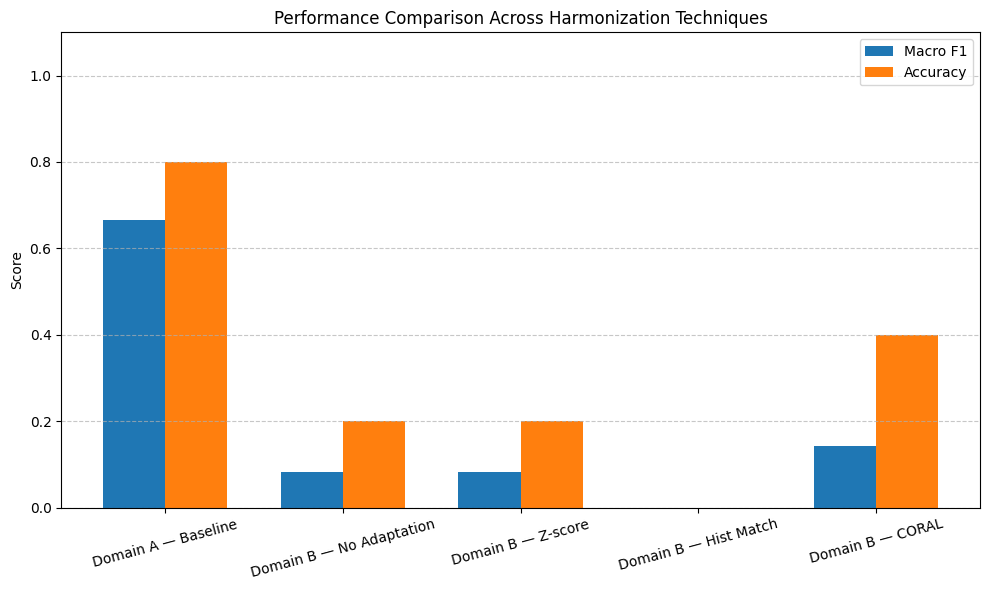

[SUCCESS] Alzheimer's Pipeline Completed.


In [103]:
from pathlib import Path

MODEL_PATH_alzheimers = Path("/Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/models/trained/best_alzheimers2.keras")
 
# Domain A: your primary training/test dataset
DOMAIN_A_DIR_alzheimers = Path("/Users/Ahmad/UNI-work/year3/FYP/Project/Research/datasets/alzheimers/domain_A")
 
# Domain B: Unseen dataset
DOMAIN_B_DIR_alzheimers = Path("/Users/Ahmad/UNI-work/year3/FYP/Project/Research/datasets/alzheimers/domain_B")
 
# Output directory for harmonized images and results
OUTPUT_DIR_alzheimers = Path("/Users/Ahmad/UNI-work/year3/FYP/Project/Research/datasets/alzheimers/output")
OUTPUT_DIR_alzheimers.mkdir(parents=True, exist_ok=True)

# Model input size
IMG_SIZE_alzheimers = (224, 224)
 
# Class mapping for your model (index → label)
LABELS_alzheimers = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']

print(run_alzheimers_pipeline(
    model_path=MODEL_PATH_alzheimers, 
    domain_a_dir=DOMAIN_A_DIR_alzheimers, 
    domain_b_dir=DOMAIN_B_DIR_alzheimers, 
    output_dir=OUTPUT_DIR_alzheimers,
    labels=LABELS_alzheimers, 
    n_explain=20
))

In [82]:
import skimage
print(skimage.__version__)

0.25.2


Now lets move to Brain Tumor

In [107]:
def load_brain_tumor_dataset(domain_dir, class_names, target_size=(224, 224)):
    """
    Custom loader for Brain Tumor MRI: Includes Cropping, Bilateral Filter, and BONE colormap.
    """
    images, labels, filenames = [], [], []
    label_map = {name: i for i, name in enumerate(class_names)}
 
    for class_name in class_names:
        class_dir = domain_dir / class_name
        if not class_dir.exists(): continue
 
        for img_path in sorted(class_dir.glob("*")):
            if img_path.suffix.lower() not in ['.png', '.jpg', '.jpeg']: continue
                
            # 1. Load in Grayscale (as per your training loop)
            img = cv2.imread(str(img_path), 0) 
            if img is None: continue
                
            # 2. Bilateral Filter to remove noise
            img = cv2.bilateralFilter(img, 2, 50, 50)
            
            # 3. Apply BONE Colormap (converts to 3-channel pseudocolor)
            img = cv2.applyColorMap(img, cv2.COLORMAP_BONE)
            
            # 4. Resize to 224x224 (your model input)
            img = cv2.resize(img, target_size)
            
            images.append(img)
            labels.append(label_map[class_name])
            filenames.append(str(img_path))
 
    images_arr = np.array(images, dtype=np.float32) / 255.0
    labels_arr = np.array(labels, dtype=np.int32)
    return images_arr, labels_arr, filenames

In [108]:
def predict_brain_tumor(model, images, batch_size=8):
    """
    Dedicated predictor for Brain Tumor model (Expects 200x200x3).
    """
    # 1. Check if we need to resize on the fly
    if images.shape[1:3] != (200, 200):
        print(f"[Warning] Resizing images from {images.shape[1:3]} to (200, 200) for Brain Tumor model.")
        import tensorflow as tf
        images_resized = tf.image.resize(images, (200, 200)).numpy()
    else:
        images_resized = images

    # 2. Get probabilities: shape (N, 4)
    all_scores = model.predict(images_resized, batch_size=batch_size, verbose=0)
    
    # 3. Get class indices: shape (N,)
    preds_arr = np.argmax(all_scores, axis=1)
    
    return all_scores, preds_arr

In [109]:
def run_brain_tumor_pipeline(model_path, domain_a_dir, domain_b_dir, output_dir, labels, n_explain=20):
    """
    Brain Tumor Runner: Uses 200x200 resolution and dedicated predictor.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    # ── STEP 1: Load Model & Data ──────────────────────────────────────────
    model = get_compiled_model(model_path)
    
    # IMPORTANT: Setting target_size to (200, 200) to match training
    print("\nLoading Domain A (200x200, BONE colormap)...")
    images_a, labels_a, _ = load_brain_tumor_dataset(domain_a_dir, labels, target_size=(200, 200))
    
    print("Loading Domain B (200x200, BONE colormap)...")
    images_b, labels_b, _ = load_brain_tumor_dataset(domain_b_dir, labels, target_size=(200, 200))

    all_results = []

    # ── STEP 2: Baseline & Domain Shift ────────────────────────────────────
    print("\nEvaluating Baseline (Domain A)...")
    # Using the NEW dedicated predictor
    scores_a, preds_a = predict_brain_tumor(model, images_a)
    all_results.append(evaluate_and_report(labels_a, preds_a, "Brain_A_Baseline", class_names=labels))

    print("\nEvaluating Raw Shift (Domain B)...")
    scores_b_raw, preds_b_raw = predict_brain_tumor(model, images_b)
    all_results.append(evaluate_and_report(labels_b, preds_b_raw, "Brain_B_Raw_Shift", class_names=labels))

    # ── STEP 3: Harmonization ──────────────────────────────────────────────
    print("\nApplying Z-Score...")
    images_b_zs = zscore_normalize(images_b, images_a)
    _, preds_zs = predict_brain_tumor(model, images_b_zs)
    all_results.append(evaluate_and_report(labels_b, preds_zs, "Brain_B_ZScore", class_names=labels))

    print("\nApplying Histogram Matching...")
    images_b_hist = histogram_match(images_b, images_a)
    _, preds_hist = predict_brain_tumor(model, images_b_hist)
    all_results.append(evaluate_and_report(labels_b, preds_hist, "Brain_B_HistMatch", class_names=labels))

    # ── STEP 4: CORAL ──────────────────────────────────────────────────────
    # extract_features and coral_align work regardless of image size
    feat_a, feat_layer = extract_features(model, images_a)
    feat_b, _          = extract_features(model, images_b, layer_name=feat_layer)
    feat_b_coral       = coral_align(feat_b, feat_a)
    
    # Reuses your previous predict_from_features logic
    _, preds_coral = predict_from_features(model, feat_b_coral, feat_layer)
    all_results.append(evaluate_and_report(labels_b, preds_coral, "Brain_B_CORAL", class_names=labels))

    # ── STEP 5: Summary ────────────────────────────────────────────────────
    plot_results_summary(all_results)
    
    return "[SUCCESS] Brain Tumor Pipeline Completed at 200x200 resolution."

Keras 3 Loader: Successfully loaded /Users/Ahmad/UNI-work/year3/FYP/Project/brain-tumor/models/trained/brain_tumor_MRI_resnet50.keras

Loading Domain A (200x200, BONE colormap)...
Loading Domain B (200x200, BONE colormap)...

Evaluating Baseline (Domain A)...

  RESULTS: Brain_A_Baseline
              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00         2
  meningioma       1.00      1.00      1.00         1
     notumor       1.00      1.00      1.00         1
   pituitary       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



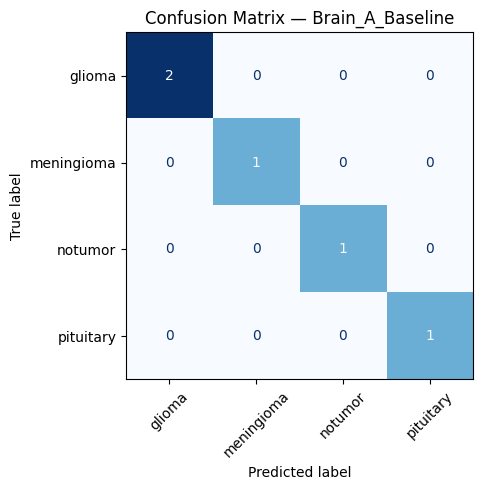


Evaluating Raw Shift (Domain B)...

  RESULTS: Brain_B_Raw_Shift
              precision    recall  f1-score   support

      glioma       0.50      1.00      0.67         1
  meningioma       0.00      0.00      0.00         1
     notumor       1.00      1.00      1.00         1
   pituitary       1.00      1.00      1.00         1

    accuracy                           0.75         4
   macro avg       0.62      0.75      0.67         4
weighted avg       0.62      0.75      0.67         4



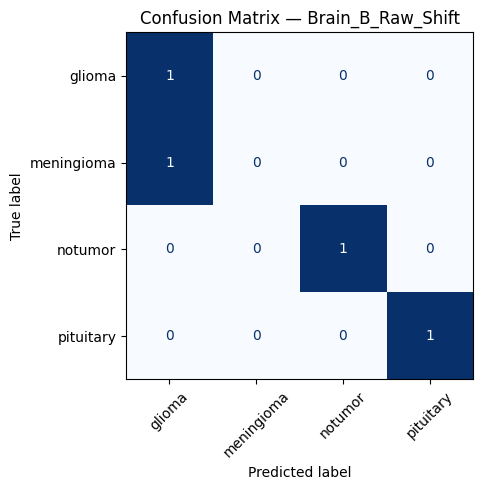


Applying Z-Score...
[Technique 1] Z-score normalization applied to 4 images
  Domain A — mean: 0.2623, std: 0.2131
  Domain B before — mean: 0.2867, std: 0.2469
  Domain B after  — mean: 0.2645,  std: 0.2040

  RESULTS: Brain_B_ZScore
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00         1
  meningioma       0.00      0.00      0.00         1
     notumor       1.00      1.00      1.00         1
   pituitary       1.00      1.00      1.00         1

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



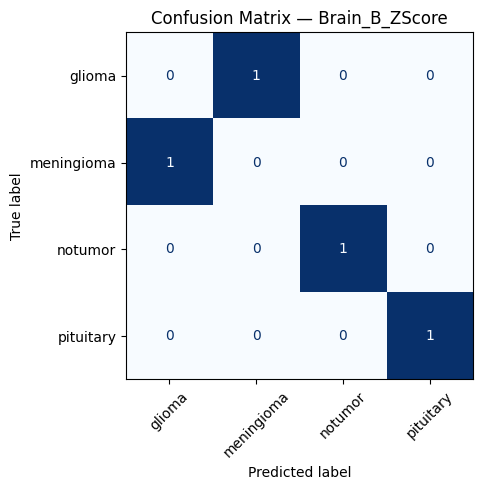


Applying Histogram Matching...
[Technique 2] Histogram matching applied to 4 images.
[Warning] Resizing images from (224, 224) to (200, 200) for Brain Tumor model.

  RESULTS: Brain_B_HistMatch
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00         1
  meningioma       0.00      0.00      0.00         1
     notumor       0.25      1.00      0.40         1
   pituitary       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.06      0.25      0.10         4
weighted avg       0.06      0.25      0.10         4



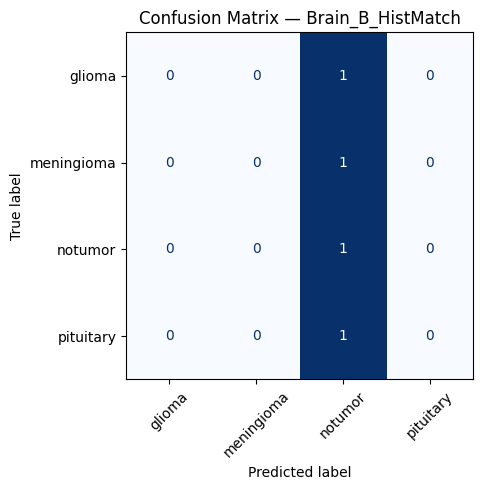

[CORAL] Extracting features from layer: 'global_average_pooling2d'
[CORAL] Extracting features from layer: 'global_average_pooling2d'
[CORAL] Alignment complete
  Domain A feature mean norm: 21.7644
  Domain B before — mean norm: 22.6518
  Domain B after  — mean norm: 12248.2344

  RESULTS: Brain_B_CORAL
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00         1
  meningioma       0.00      0.00      0.00         1
     notumor       0.25      1.00      0.40         1
   pituitary       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.06      0.25      0.10         4
weighted avg       0.06      0.25      0.10         4



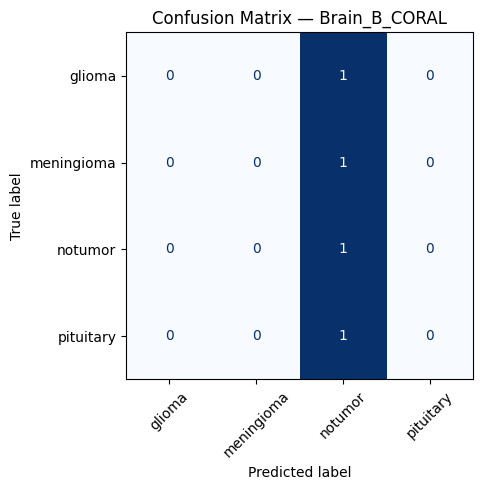

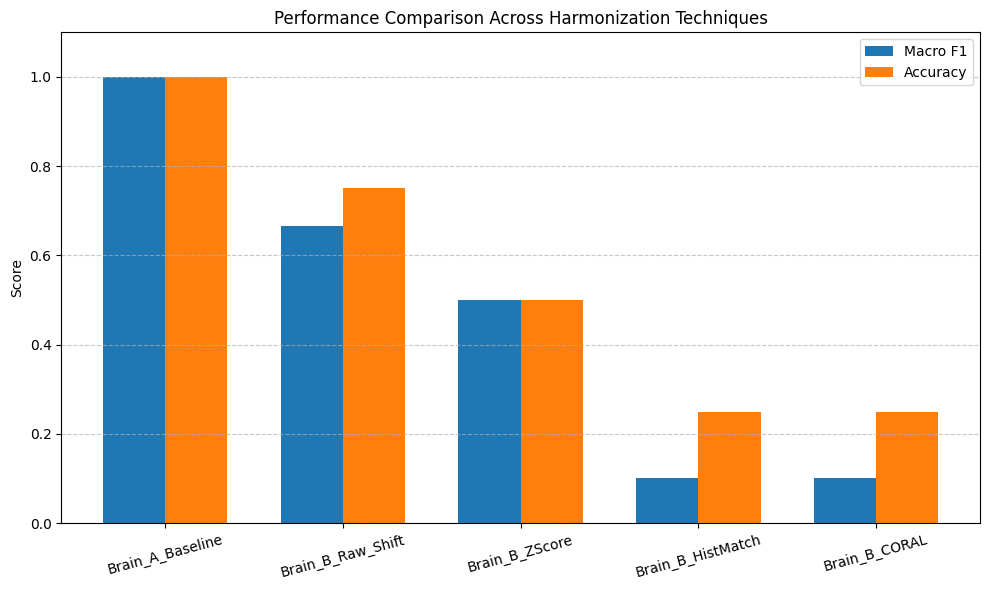

[SUCCESS] Brain Tumor Pipeline Completed at 200x200 resolution.


In [113]:
from pathlib import Path

MODEL_PATH_brain = Path("/Users/Ahmad/UNI-work/year3/FYP/Project/brain-tumor/models/trained/brain_tumor_MRI_resnet50.keras")
 
# Domain A: your primary training/test dataset
DOMAIN_A_DIR_brain = Path("/Users/Ahmad/UNI-work/year3/FYP/Project/Research/datasets/brain-tumor/domain_A")
 
# Domain B: Unseen dataset
DOMAIN_B_DIR_brain = Path("/Users/Ahmad/UNI-work/year3/FYP/Project/Research/datasets/brain-tumor/domain_B")
 
# Output directory for harmonized images and results
OUTPUT_DIR_brain = Path("/Users/Ahmad/UNI-work/year3/FYP/Project/Research/datasets/brain-tumor/output")
OUTPUT_DIR_brain.mkdir(parents=True, exist_ok=True)

# Model input size
IMG_SIZE_brain = (200, 200)
 
# Class mapping for your model (index → label)
LABELS_brain = ['glioma', 'meningioma', 'notumor', 'pituitary']

print(run_brain_tumor_pipeline(
    model_path=MODEL_PATH_brain, 
    domain_a_dir=DOMAIN_A_DIR_brain, 
    domain_b_dir=DOMAIN_B_DIR_brain, 
    output_dir=OUTPUT_DIR_brain,
    labels=LABELS_brain, 
    n_explain=20
))